In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [14]:
data = pd.read_csv("IRIS.csv")
X = data[["sepal_length","sepal_width","petal_length","petal_width"]].fillna(0)

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
wcss = []
for k in range(2, 11):
    wcss.append(KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X).inertia_)

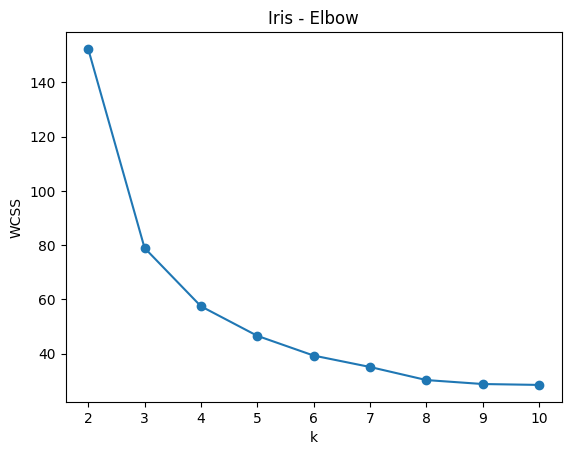

In [17]:
plt.plot(range(2, 11), wcss, marker="o")
plt.title("Iris - Elbow")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

In [19]:
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init="auto")
data["Cluster"] = model.fit_predict(X)

In [23]:
print("Silhouette Score:", silhouette_score(X, data["Cluster"]))

data.to_csv("Iris_clustered.csv", index=False)



Silhouette Score: 0.5509643746707443


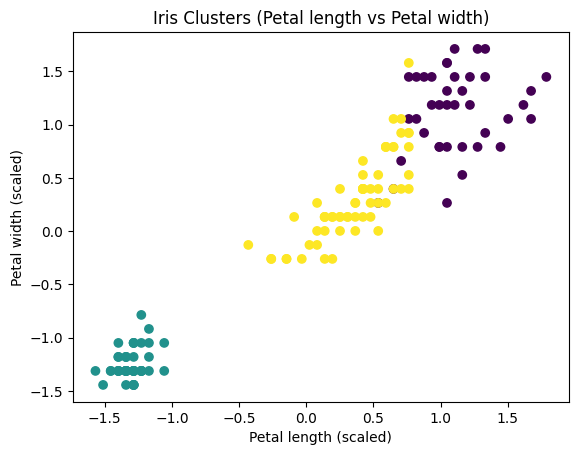

In [25]:
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=data["Cluster"])
plt.title("Iris Clusters (Petal length vs Petal width)")
plt.xlabel("Petal length (scaled)")
plt.ylabel("Petal width (scaled)")
plt.show()